# 01 — Real-world market data

Download, inspect, clean, and save the four-asset dataset used downstream. The selected stocks are:

- **AAPL:** technology and growth exposure,
- **JPM:** banking and credit-cycle exposure,
- **XOM:** energy and commodity-cycle exposure,
- **WMT:** defensive consumer and retail exposure.

The window begins in 2007 and ends after 2025, covering the Global Financial Crisis, the COVID crash and recovery, and the 2022 tightening regime. The selection intentionally favors firms with complete histories, so results are subject to survivorship bias. Yahoo Finance data accessed through `yfinance` are suitable for research prototyping, not production trading.

In [1]:
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

ROOT = Path.cwd()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / 'src'))

from innovcal.data.market import clean_adjusted_prices, download_adjusted_prices

## Download configuration

`yfinance` treats the end date as exclusive, so `2026-01-01` includes observations through the end of 2025. Keeping the window fixed makes later runs reproducible.

In [2]:
TICKERS = ('AAPL', 'JPM', 'XOM', 'WMT')
START = '2007-01-01'
END_EXCLUSIVE = '2026-01-01'

downloaded_prices = download_adjusted_prices(
    TICKERS, start=START, end=END_EXCLUSIVE
)
print('downloaded shape:', downloaded_prices.shape)
print('observed range:', downloaded_prices.index.min(), 'to', downloaded_prices.index.max())
downloaded_prices.head()

downloaded shape: (4780, 4)
observed range: 2007-01-03 00:00:00 to 2025-12-31 00:00:00


Ticker,AAPL,JPM,XOM,WMT
Date,,,,
2007-01-03,2.506428,29.259199,37.524399,10.658487
2007-01-04,2.562060,29.332243,36.820591,10.710043
2007-01-05,2.543814,29.088774,37.083889,10.622624
2007-01-08,2.556376,29.186146,36.785156,10.535204
2007-01-09,2.768734,29.064440,36.501602,10.622624


## Data-quality audit

Missing values are measured before alignment. The cleaning function rejects any ticker with more than 1% missing adjusted prices instead of silently imputing market prices. Remaining isolated missing dates are removed jointly so every row has all four assets.

In [3]:
quality = pd.DataFrame({
    'missing_count': downloaded_prices.isna().sum(),
    'missing_fraction': downloaded_prices.isna().mean(),
    'first_valid': downloaded_prices.apply(pd.Series.first_valid_index),
    'last_valid': downloaded_prices.apply(pd.Series.last_valid_index),
    'minimum': downloaded_prices.min(),
    'maximum': downloaded_prices.max(),
})
quality

,missing_count,missing_fraction,first_valid,last_valid,minimum,maximum
Ticker,,,,,,
AAPL,0,0.0,2007-01-03,2025-12-31,2.338933,285.413116
JPM,0,0.0,2007-01-03,2025-12-31,10.387362,324.561249
XOM,0,0.0,2007-01-03,2025-12-31,23.670288,118.610596
WMT,0,0.0,2007-01-03,2025-12-31,9.612760,116.050972


In [4]:
cleaned_prices, returns = clean_adjusted_prices(
    downloaded_prices, maximum_missing_fraction=0.01
)
assert list(cleaned_prices.columns) == list(TICKERS)
assert cleaned_prices.notna().all().all()
assert returns.notna().all().all()
assert (cleaned_prices > 0).all().all()
print('cleaned prices:', cleaned_prices.shape)
print('log returns:', returns.shape)
returns.describe().T

cleaned prices: (4780, 4)
log returns: (4779, 4)


,count,mean,std,min,25%,50%,75%,max
Ticker,,,,,,,,
AAPL,4779.0,0.000980,0.019793,-0.197470,-0.007833,0.001094,0.011151,0.142617
JPM,4779.0,0.000499,0.023427,-0.232278,-0.008328,0.000540,0.009582,0.223917
XOM,4779.0,0.000240,0.016958,-0.150271,-0.007653,0.000246,0.008483,0.158631
WMT,4779.0,0.000490,0.013044,-0.120765,-0.005550,0.000659,0.006635,0.110723


## Visual checks

Prices are normalized to 100 at the start for comparability. The shaded markers locate the two principal crisis windows motivating this sample.

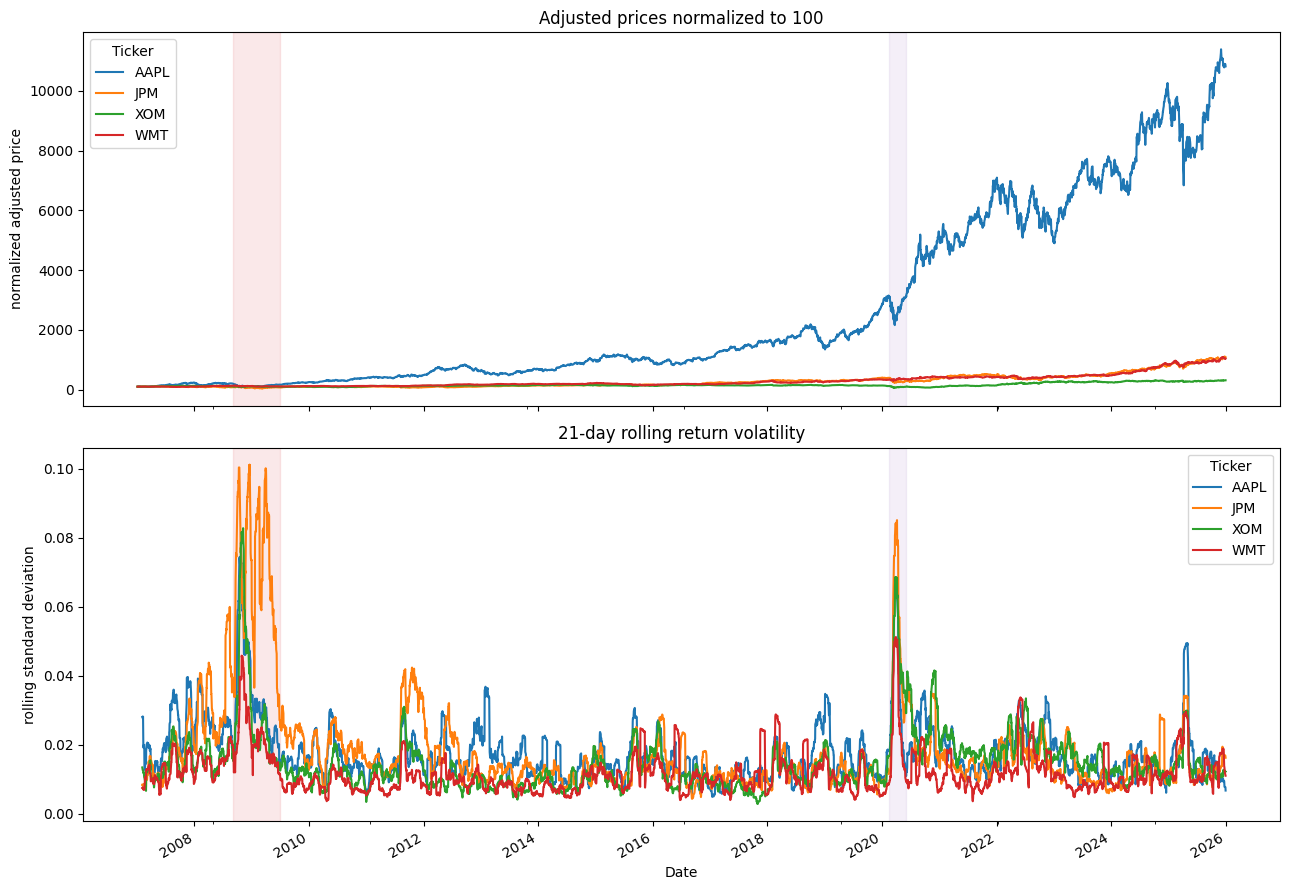

In [5]:
normalized = 100 * cleaned_prices / cleaned_prices.iloc[0]
fig, axes = plt.subplots(2, 1, figsize=(13, 9), sharex=True)
normalized.plot(ax=axes[0], title='Adjusted prices normalized to 100')
returns.rolling(21).std().plot(ax=axes[1], title='21-day rolling return volatility')
for axis in axes:
    axis.axvspan('2008-09-01', '2009-06-30', color='tab:red', alpha=0.10, label='GFC')
    axis.axvspan('2020-02-15', '2020-05-31', color='tab:purple', alpha=0.10, label='COVID shock')
axes[0].set_ylabel('normalized adjusted price')
axes[1].set_ylabel('rolling standard deviation')
plt.tight_layout();

## Save canonical datasets

The downstream notebooks consume `financial_returns.csv`. Cleaned adjusted prices and acquisition metadata are saved alongside it for auditability.

In [6]:
RAW_OUTPUT = ROOT / 'data/raw/yahoo_adjusted_prices.csv'
PRICE_OUTPUT = ROOT / 'data/processed/market_prices.csv'
RETURN_OUTPUT = ROOT / 'data/processed/financial_returns.csv'
METADATA_OUTPUT = ROOT / 'data/processed/market_data_metadata.json'

RAW_OUTPUT.parent.mkdir(parents=True, exist_ok=True)
PRICE_OUTPUT.parent.mkdir(parents=True, exist_ok=True)
downloaded_prices.to_csv(RAW_OUTPUT, index_label='Date')
cleaned_prices.to_csv(PRICE_OUTPUT, index_label='Date')
returns.to_csv(RETURN_OUTPUT, index_label='Date')
metadata = {
    'source': 'Yahoo Finance via yfinance',
    'tickers': list(TICKERS),
    'requested_start': START,
    'requested_end_exclusive': END_EXCLUSIVE,
    'observed_start': str(cleaned_prices.index.min().date()),
    'observed_end': str(cleaned_prices.index.max().date()),
    'price_rows': len(cleaned_prices),
    'return_rows': len(returns),
    'price_field': 'Adj Close',
    'return_definition': 'one-day log difference of adjusted close',
    'missing_policy': 'reject >1% by ticker, then complete-case alignment',
    'known_limitation': 'survivorship-biased selection of long-lived firms',
}
METADATA_OUTPUT.write_text(json.dumps(metadata, indent=2))
print('saved:', PRICE_OUTPUT)
print('saved:', RETURN_OUTPUT)
metadata

saved: /Users/jonathanma/Desktop/Projects/innovative-droBVAR/data/processed/market_prices.csv
saved: /Users/jonathanma/Desktop/Projects/innovative-droBVAR/data/processed/financial_returns.csv


{'source': 'Yahoo Finance via yfinance',
 'tickers': ['AAPL', 'JPM', 'XOM', 'WMT'],
 'requested_start': '2007-01-01',
 'requested_end_exclusive': '2026-01-01',
 'observed_start': '2007-01-03',
 'observed_end': '2025-12-31',
 'price_rows': 4780,
 'return_rows': 4779,
 'price_field': 'Adj Close',
 'return_definition': 'one-day log difference of adjusted close',
 'missing_policy': 'reject >1% by ticker, then complete-case alignment',
 'known_limitation': 'survivorship-biased selection of long-lived firms'}